In [ ]:
import pandas as pd

path = r"/content/healthcare_patient_dataset.csv"

df = pd.read_csv(path)
df

,patient_id,age,gender,bmi,blood_pressure_sys,blood_sugar,city,smoker_status,diagnosis_risk
0,4748,29,P,NaN,137.9,111.6,Kota_073,Yes,Medium
1,1200,65,L,20.9,146.8,132.8,Kota_001,No,Low
2,5223,42,L,26.9,154.3,50.6,Kota_005,Yes,Medium
3,4548,44,L,NaN,116.5,85.9,Kota_057,No,Low
4,1863,57,P,28.3,100.6,160.0,Kota_064,No,High
...,...,...,...,...,...,...,...,...,...
5495,3773,33,L,37.2,115.7,115.6,Kota_079,Yes,Medium
5496,5192,44,P,33.8,126.7,475.0,Kota_082,No,Low
5497,5227,39,L,24.3,99.8,146.6,Kota_058,No,Medium
5498,5391,35,P,25.1,116.2,86.6,Kota_111,No,Low


In [ ]:
#jumlah blank
blank = df['bmi'].isnull().sum()
jumlah_data_bmi = len(df["bmi"])
print(f"Jumlah blank = {blank}, Jumlah data bmi = {jumlah_data_bmi}, Presentase Blank = {round(blank/jumlah_data_bmi*100,2)}%")

Jumlah blank = 267, Jumlah data bmi = 5500, Presentase Blank = 4.85%


In [ ]:
median_bmi = df['bmi'].median()
df['bmi'] = df['bmi'].fillna(median_bmi)
mean_bmi = round(df["bmi"].mean(),2)
mean_blood_sugar = round(df['blood_sugar'].mean(),2)
std_bmi = round(df["bmi"].std(),2)
std_blood_sugar = round(df["blood_sugar"].std(),2)
df['z_score_bmi'] = (df['bmi'] - mean_bmi) / std_bmi
df['z_score_outlier_bmi'] = (df['z_score_bmi'] < -3) | (df['z_score_bmi'] > 3)
df['z_score_blood_sugar'] = (df['blood_sugar'] - mean_blood_sugar) / std_blood_sugar
df['z_score_outlier_blood_sugar'] = (df['z_score_blood_sugar'] < -3) | (df['z_score_blood_sugar'] > 3)
df

,patient_id,age,gender,bmi,blood_pressure_sys,blood_sugar,city,smoker_status,diagnosis_risk,z_score_bmi,z_score_outlier_bmi,z_score_blood_sugar,z_score_outlier_blood_sugar
0,4748,29,P,26.1,137.9,111.6,Kota_073,Yes,Medium,-0.101124,False,-0.062686,False
1,1200,65,L,20.9,146.8,132.8,Kota_001,No,Low,-0.831461,False,0.189006,False
2,5223,42,L,26.9,154.3,50.6,Kota_005,Yes,Medium,0.011236,False,-0.786893,False
3,4548,44,L,26.1,116.5,85.9,Kota_057,No,Low,-0.101124,False,-0.367802,False
4,1863,57,P,28.3,100.6,160.0,Kota_064,No,High,0.207865,False,0.511932,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,3773,33,L,37.2,115.7,115.6,Kota_079,Yes,Medium,1.457865,False,-0.015196,False
5496,5192,44,P,33.8,126.7,475.0,Kota_082,No,Low,0.980337,False,4.251692,True
5497,5227,39,L,24.3,99.8,146.6,Kota_058,No,Medium,-0.353933,False,0.352843,False
5498,5391,35,P,25.1,116.2,86.6,Kota_111,No,Low,-0.241573,False,-0.359492,False


In [ ]:
df.describe()

,patient_id,age,bmi,blood_pressure_sys,blood_sugar,z_score_bmi,z_score_blood_sugar
count,5500.000000,5500.000000,5500.000000,4950.000000,5500.000000,5500.000000,5500.000000
mean,2750.500000,45.229455,26.824073,122.188323,116.884182,0.000572,0.000050
std,1587.857571,14.417125,7.121500,15.981256,84.234266,1.000211,1.000051
min,1.000000,18.000000,14.000000,80.000000,50.000000,-1.800562,-0.794016
25%,1375.750000,35.000000,23.200000,111.300000,79.500000,-0.508427,-0.443785
50%,2750.500000,45.000000,26.100000,122.150000,101.000000,-0.101124,-0.188531
75%,4125.250000,55.000000,29.000000,133.300000,128.100000,0.306180,0.133207
max,5500.000000,90.000000,75.000000,193.700000,999.000000,6.766854,10.472753


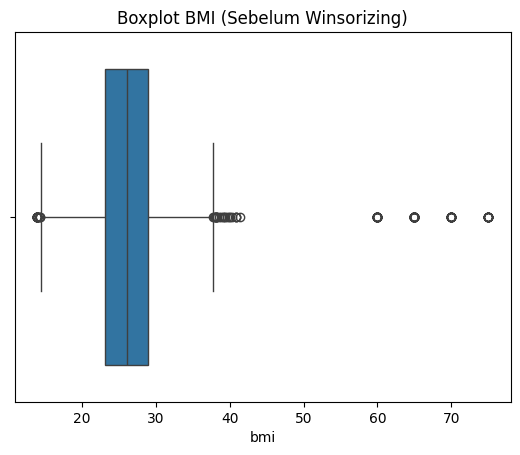

In [ ]:
#visualisasi bmi
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=df['bmi'])
plt.title('Boxplot BMI (Sebelum Winsorizing)')
plt.show()

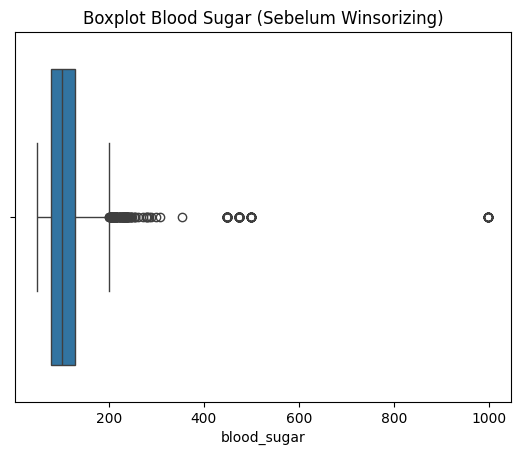

In [ ]:
sns.boxplot(x=df['blood_sugar'])
plt.title('Boxplot Blood Sugar (Sebelum Winsorizing)')
plt.show()

In [ ]:
#IQR
Q1_bmi = df["bmi"].quantile(0.25)
Q3_bmi = df["bmi"].quantile(0.75)
IQR_bmi = Q3_bmi - Q1_bmi
lower_bmi = round(Q1_bmi - 1.5 * IQR_bmi,2)
upper_bmi = round(Q3_bmi + 1.5 * IQR_bmi,2)

print(f"Batas bawah = {lower_bmi}, Batas atas = {upper_bmi}")

Batas bawah = 14.5, Batas atas = 37.7


In [ ]:
Q1_blood_sugar = df["blood_sugar"].quantile(0.25)
Q3_blood_sugar = df["blood_sugar"].quantile(0.75)
IQR_blood_sugar = Q3_blood_sugar - Q1_blood_sugar
lower_blood_sugar = round(Q1_blood_sugar - 1.5 * IQR_blood_sugar,2)
upper_blood_sugar = round(Q3_blood_sugar + 1.5 * IQR_blood_sugar,2)

print(f"Batas bawah = {lower_blood_sugar}, Batas atas = {upper_blood_sugar}")

Batas bawah = 6.6, Batas atas = 201.0


In [ ]:
df_bmi = df.iloc[:,1:11]
df_bmi['upper'] = upper_bmi
df_bmi['lower'] = lower_bmi
df_bmi['winsorized_bmi'] = df['bmi'].clip(
    lower = lower_bmi,
    upper = upper_bmi
)
df_bmi

,age,gender,bmi,blood_pressure_sys,blood_sugar,city,smoker_status,diagnosis_risk,z_score_bmi,z_score_outlier_bmi,upper,lower,winsorized_bmi
0,29,P,26.1,137.9,111.6,Kota_073,Yes,Medium,-0.101124,False,37.7,14.5,26.1
1,65,L,20.9,146.8,132.8,Kota_001,No,Low,-0.831461,False,37.7,14.5,20.9
2,42,L,26.9,154.3,50.6,Kota_005,Yes,Medium,0.011236,False,37.7,14.5,26.9
3,44,L,26.1,116.5,85.9,Kota_057,No,Low,-0.101124,False,37.7,14.5,26.1
4,57,P,28.3,100.6,160.0,Kota_064,No,High,0.207865,False,37.7,14.5,28.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,33,L,37.2,115.7,115.6,Kota_079,Yes,Medium,1.457865,False,37.7,14.5,37.2
5496,44,P,33.8,126.7,475.0,Kota_082,No,Low,0.980337,False,37.7,14.5,33.8
5497,39,L,24.3,99.8,146.6,Kota_058,No,Medium,-0.353933,False,37.7,14.5,24.3
5498,35,P,25.1,116.2,86.6,Kota_111,No,Low,-0.241573,False,37.7,14.5,25.1


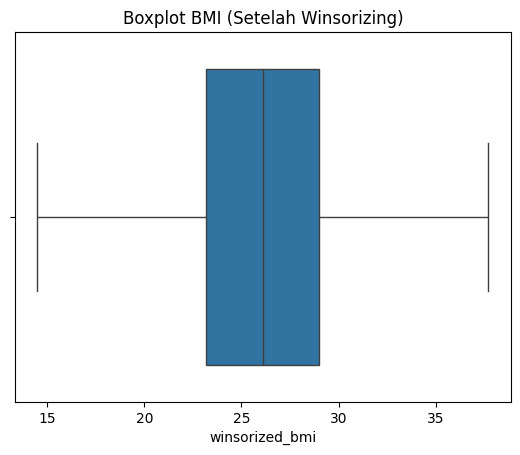

In [ ]:
sns.boxplot(x=df_bmi['winsorized_bmi'])
plt.title('Boxplot BMI (Setelah Winsorizing)')
plt.show()

In [ ]:
df_blood_sugar = df.iloc[:,1:11]
df_blood_sugar['upper'] = upper_blood_sugar
df_blood_sugar['lower'] = lower_blood_sugar
df_blood_sugar['winsorized_blood_sugar'] = df['blood_sugar'].clip(
    lower = lower_blood_sugar,
    upper = upper_blood_sugar
)
df_blood_sugar

,age,gender,bmi,blood_pressure_sys,blood_sugar,city,smoker_status,diagnosis_risk,z_score_bmi,z_score_outlier_bmi,upper,lower,winsorized_blood_sugar
0,29,P,26.1,137.9,111.6,Kota_073,Yes,Medium,-0.101124,False,201.0,6.6,111.6
1,65,L,20.9,146.8,132.8,Kota_001,No,Low,-0.831461,False,201.0,6.6,132.8
2,42,L,26.9,154.3,50.6,Kota_005,Yes,Medium,0.011236,False,201.0,6.6,50.6
3,44,L,26.1,116.5,85.9,Kota_057,No,Low,-0.101124,False,201.0,6.6,85.9
4,57,P,28.3,100.6,160.0,Kota_064,No,High,0.207865,False,201.0,6.6,160.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,33,L,37.2,115.7,115.6,Kota_079,Yes,Medium,1.457865,False,201.0,6.6,115.6
5496,44,P,33.8,126.7,475.0,Kota_082,No,Low,0.980337,False,201.0,6.6,201.0
5497,39,L,24.3,99.8,146.6,Kota_058,No,Medium,-0.353933,False,201.0,6.6,146.6
5498,35,P,25.1,116.2,86.6,Kota_111,No,Low,-0.241573,False,201.0,6.6,86.6


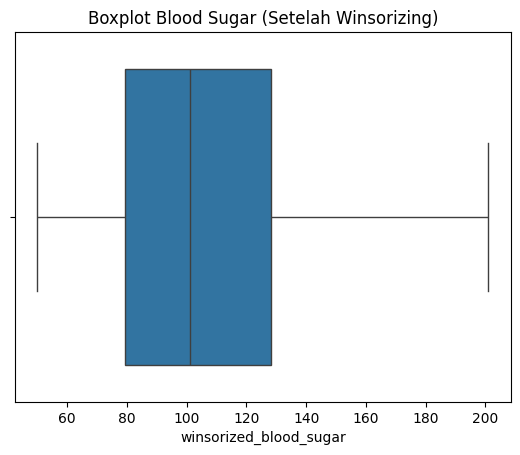

In [ ]:
sns.boxplot(x=df_blood_sugar['winsorized_blood_sugar'])
plt.title('Boxplot Blood Sugar (Setelah Winsorizing)')
plt.show()

In [ ]:
#kelebihannya jika memakai winsorizing + IQR adalah tidak ada data yg dibuang dan lebih robust terhadap outlier. basisnya adalah median dan kuartil
#bedanya jika hanya memakai Z Score, Z Score sangat rentan terhadap outlier ekstrim
#jika outlier dihapus maka histogram akan berubah bentuk

In [ ]:
#before stats
df['blood_pressure_sys'].describe()

,blood_pressure_sys
count,4950.000000
mean,122.188323
std,15.981256
min,80.000000
25%,111.300000
50%,122.150000
75%,133.300000
max,193.700000


In [ ]:
median_blood_pressure = df['blood_pressure_sys'].median()
df['blood_pressure_sys'] = df['blood_pressure_sys'].fillna(median_blood_pressure)
df['blood_pressure_sys'].describe()

,blood_pressure_sys
count,5500.000000
mean,122.184491
std,15.161002
min,80.000000
25%,112.600000
50%,122.150000
75%,131.825000
max,193.700000


In [ ]:
blank_before = df['smoker_status'].isnull().sum()
print(f"Jumlah blank sebelum imputasi = {blank_before}")

Jumlah blank sebelum imputasi = 440


In [ ]:
mode_smoker = df['smoker_status'].mode()[0]
df['smoker_status'] = df['smoker_status'].fillna(mode_smoker)
blank_after = df['smoker_status'].isnull().sum()
print(f"Jumlah blank sesudah imputasi = {blank_after}")

Jumlah blank sesudah imputasi = 0


In [ ]:
#jika terjadi kesalahan pada imputasi maka bisa menyebabkan bias hasil riset sehingga diagnosis ke pasien juga menjadi salah

In [ ]:
maping = {
    'Low' : 0,
    'Medium' : 1,
    'High' : 2
}
df['diagnosis_risk_encoded'] = df['diagnosis_risk'].map(maping)
df

,patient_id,age,gender,bmi,blood_pressure_sys,blood_sugar,city,smoker_status,diagnosis_risk,z_score_bmi,z_score_outlier_bmi,z_score_blood_sugar,z_score_outlier_blood_sugar,diagnosis_risk_encoded
0,4748,29,P,26.1,137.9,111.6,Kota_073,Yes,Medium,-0.101124,False,-0.062686,False,1
1,1200,65,L,20.9,146.8,132.8,Kota_001,No,Low,-0.831461,False,0.189006,False,0
2,5223,42,L,26.9,154.3,50.6,Kota_005,Yes,Medium,0.011236,False,-0.786893,False,1
3,4548,44,L,26.1,116.5,85.9,Kota_057,No,Low,-0.101124,False,-0.367802,False,0
4,1863,57,P,28.3,100.6,160.0,Kota_064,No,High,0.207865,False,0.511932,False,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,3773,33,L,37.2,115.7,115.6,Kota_079,Yes,Medium,1.457865,False,-0.015196,False,1
5496,5192,44,P,33.8,126.7,475.0,Kota_082,No,Low,0.980337,False,4.251692,True,0
5497,5227,39,L,24.3,99.8,146.6,Kota_058,No,Medium,-0.353933,False,0.352843,False,1
5498,5391,35,P,25.1,116.2,86.6,Kota_111,No,Low,-0.241573,False,-0.359492,False,0


In [ ]:
freq_encoding = df['city'].value_counts()
df['city_encoded'] = df['city'].map(freq_encoding)
df

,patient_id,age,gender,bmi,blood_pressure_sys,blood_sugar,city,smoker_status,diagnosis_risk,z_score_bmi,z_score_outlier_bmi,z_score_blood_sugar,z_score_outlier_blood_sugar,diagnosis_risk_encoded,city_encoded
0,4748,29,P,26.1,137.9,111.6,Kota_073,Yes,Medium,-0.101124,False,-0.062686,False,1,46
1,1200,65,L,20.9,146.8,132.8,Kota_001,No,Low,-0.831461,False,0.189006,False,0,73
2,5223,42,L,26.9,154.3,50.6,Kota_005,Yes,Medium,0.011236,False,-0.786893,False,1,38
3,4548,44,L,26.1,116.5,85.9,Kota_057,No,Low,-0.101124,False,-0.367802,False,0,66
4,1863,57,P,28.3,100.6,160.0,Kota_064,No,High,0.207865,False,0.511932,False,2,231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,3773,33,L,37.2,115.7,115.6,Kota_079,Yes,Medium,1.457865,False,-0.015196,False,1,131
5496,5192,44,P,33.8,126.7,475.0,Kota_082,No,Low,0.980337,False,4.251692,True,0,92
5497,5227,39,L,24.3,99.8,146.6,Kota_058,No,Medium,-0.353933,False,0.352843,False,1,33
5498,5391,35,P,25.1,116.2,86.6,Kota_111,No,Low,-0.241573,False,-0.359492,False,0,30


In [ ]:
# dampaknya jika salah memilih encoding adalah misal data ordinal bukan urutan
#contoh male = 1 , female = 2
# model akan mengira female lebih tinggi dibanding male

In [ ]:
min_age = df['age'].min()
max_age = df['age'].max()
df['age_skala'] = (df['age'] - min_age) / (max_age - min_age)
df

,patient_id,age,gender,bmi,blood_pressure_sys,blood_sugar,city,smoker_status,diagnosis_risk,z_score_bmi,z_score_outlier_bmi,z_score_blood_sugar,z_score_outlier_blood_sugar,diagnosis_risk_encoded,city_encoded,age_skala
0,4748,29,P,26.1,137.9,111.6,Kota_073,Yes,Medium,-0.101124,False,-0.062686,False,1,46,0.152778
1,1200,65,L,20.9,146.8,132.8,Kota_001,No,Low,-0.831461,False,0.189006,False,0,73,0.652778
2,5223,42,L,26.9,154.3,50.6,Kota_005,Yes,Medium,0.011236,False,-0.786893,False,1,38,0.333333
3,4548,44,L,26.1,116.5,85.9,Kota_057,No,Low,-0.101124,False,-0.367802,False,0,66,0.361111
4,1863,57,P,28.3,100.6,160.0,Kota_064,No,High,0.207865,False,0.511932,False,2,231,0.541667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,3773,33,L,37.2,115.7,115.6,Kota_079,Yes,Medium,1.457865,False,-0.015196,False,1,131,0.208333
5496,5192,44,P,33.8,126.7,475.0,Kota_082,No,Low,0.980337,False,4.251692,True,0,92,0.361111
5497,5227,39,L,24.3,99.8,146.6,Kota_058,No,Medium,-0.353933,False,0.352843,False,1,33,0.291667
5498,5391,35,P,25.1,116.2,86.6,Kota_111,No,Low,-0.241573,False,-0.359492,False,0,30,0.236111


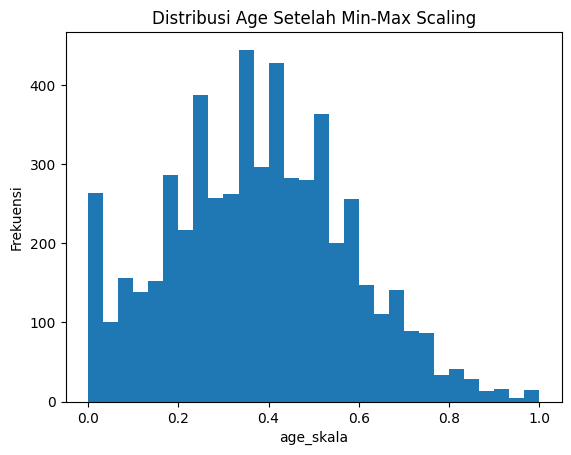

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['age_skala'], bins=30)
plt.title('Distribusi Age Setelah Min-Max Scaling')
plt.xlabel('age_skala')
plt.ylabel('Frekuensi')
plt.show()


In [ ]:
age_median = df['age'].median()
robust_q1 = df['age'].quantile(0.25)
robust_q3 = df['age'].quantile(0.75)
iqr_age = robust_q3 - robust_q1
df['robust_age'] = (df['age'] - age_median) / iqr_age
df['robust_age']


,robust_age
0,-0.80
1,1.00
2,-0.15
3,-0.05
4,0.60
...,...
5495,-0.60
5496,-0.05
5497,-0.30
5498,-0.50


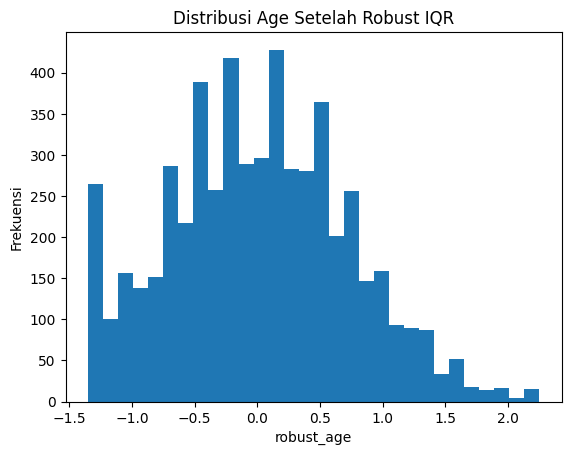

In [ ]:
plt.hist(df['robust_age'], bins=30)
plt.title('Distribusi Age Setelah Robust IQR')
plt.xlabel('robust_age')
plt.ylabel('Frekuensi')
plt.show()

In [ ]:
#Jelaskan mengapa scaling penting dalam model prediksi risiko pasien.
#penting karena untuk menghindari dominasi fitur besar
#contoh
#age : 0 - 100
#blood sugar : 0 -300
#Tanpa scaling maka blood sugar lebih dominan

Text(0.5, 1.0, 'Setelah Log Transform')

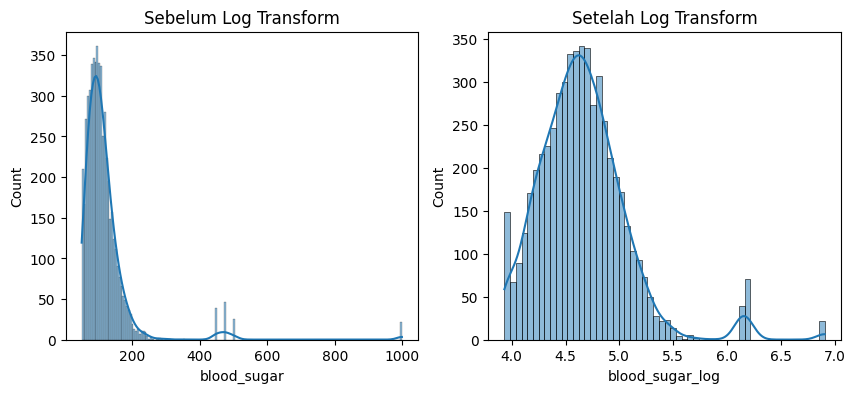

In [ ]:
import numpy as np

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['blood_sugar'], kde=True)
plt.title('Sebelum Log Transform')

df['blood_sugar_log'] = np.log1p(df['blood_sugar']) # np.log1p() handles values near zero

plt.subplot(1, 2, 2)
sns.histplot(df['blood_sugar_log'], kde=True)
plt.title('Setelah Log Transform')

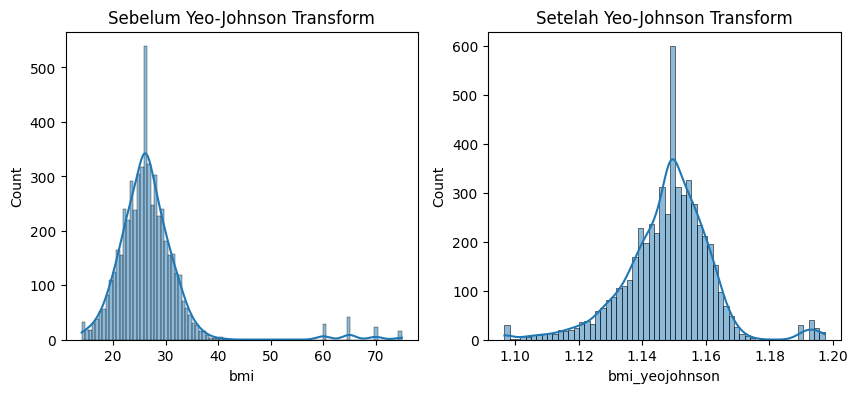

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

plt.figure(figsize=(10,4))

# sebelum transform
plt.subplot(1,2,1)
sns.histplot(df['bmi'], kde=True)
plt.title('Sebelum Yeo-Johnson Transform')

# transform
df['bmi_yeojohnson'], lmbda = stats.yeojohnson(df['bmi'])

# sesudah transform
plt.subplot(1,2,2)
sns.histplot(df['bmi_yeojohnson'], kde=True)
plt.title('Setelah Yeo-Johnson Transform')

plt.show()


In [ ]:
#Jelaskan mengapa scaling penting dalam model prediksi risiko pasien.
#saat dipakai untuk diagnosis langsung

In [ ]:
df['diagnosis_risk'].value_counts()

,count
diagnosis_risk,
Low,2956
Medium,1983
High,561


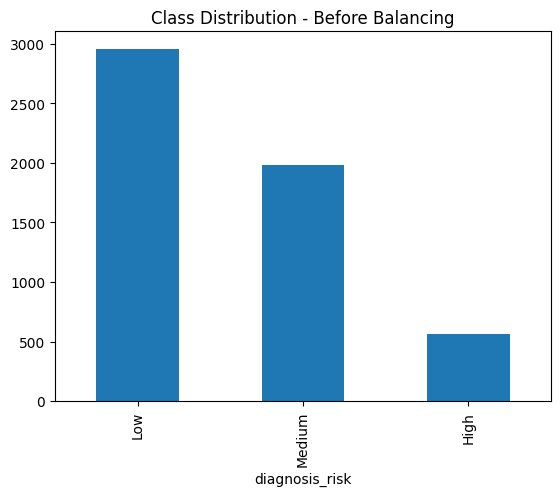

In [ ]:
df['diagnosis_risk'].value_counts().plot(kind='bar')
plt.title('Class Distribution - Before Balancing')
plt.show()

In [ ]:
df['diagnosis_risk'].value_counts(normalize=True)

,proportion
diagnosis_risk,
Low,0.537455
Medium,0.360545
High,0.102000


In [ ]:
# 0. Import
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Split fitur & target

X = df.drop(columns=['diagnosis_risk'])
y = df['diagnosis_risk']

# 2. Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    random_state=42,
    test_size=0.2
)

# 3. Encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_enc = encoder.fit_transform(X_train)
X_test_enc  = encoder.transform(X_test)


# 4. Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)


# 5. SMOTE
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:", X_train_scaled.shape, y_train.shape)
print("After SMOTE :", X_train_sm.shape, y_train_sm.shape)


Before SMOTE: (4400, 10218) (4400,)
After SMOTE : (7095, 10218) (7095,)


In [ ]:
from collections import Counter

print("Before SMOTE :", Counter(y_train))
print("After SMOTE  :", Counter(y_train_sm))

Before SMOTE : Counter({'Low': 2365, 'Medium': 1586, 'High': 449})
After SMOTE  : Counter({'Low': 2365, 'Medium': 2365, 'High': 2365})


In [ ]:
#Jelaskan risiko oversampling yang berlebihan pada data medis
#distribusi penyakit jadi tidak realistis misalnya high risk pasien sebenernya cuman 10% tetapi setelah oversampling model menganggap high risk pasien sama banyaknya dengan low risk pasien